# IET SMP Assignment: Variational Autoencoders (VAE) with MNIST

**Total Marks: 20**

**Instructions:**
- Read each question carefully.
- Write the required code and brief explanations in the notebook cells provided.
- Run all code cells after completing the assignment.
- Keep your answers clear, concise, and well-organized.

### Assignment Overview
This notebook is structured as a short practical assignment on Variational Autoencoders using the MNIST dataset. You will define the model, train it, and generate new handwritten digit samples.

### Mark Distribution
- Concept of VAE and latent space: **3 marks**
- Encoder design and reparameterization trick: **5 marks**
- VAE loss function: **4 marks**
- Training setup and loop: **5 marks**
- Generating new digits and interpretation: **3 marks**


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Set device to GPU if available for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


### Question 1: VAE Concept, Encoder Design, and Reparameterization Trick [8 marks]

Explain the purpose of a Variational Autoencoder and how its latent space differs from that of a standard autoencoder.

Then describe how the VAE encoder produces the latent distribution parameters and why the reparameterization trick is required for backpropagation.

In your answer, include:
- the role of mean ($\mu$)
- the role of log-variance ($\log(\sigma^2)$)
- how $z = \mu + \sigma \odot \epsilon$ supports training

---

**Answer:**

**Purpose of a VAE.** A Variational Autoencoder is a generative model that learns a probabilistic mapping between data (e.g. images) and a continuous latent space. Unlike a plain autoencoder, which only learns to compress and reconstruct a specific input deterministically, a VAE learns the *distribution* of the data so that new, realistic samples can be generated by drawing random points from the latent space and decoding them.

**Latent space: VAE vs. standard autoencoder.**
- A standard autoencoder maps each input to a single fixed point $z$ in latent space. Nothing forces nearby points in that space to decode to meaningful images, so the latent space can have gaps and is not generally usable for sampling new data.
- A VAE instead maps each input to a *probability distribution* (typically a Gaussian) over the latent space, parameterized by a mean $\mu$ and variance $\sigma^2$. During training, a KL-divergence penalty forces all these per-input Gaussians toward a standard normal prior $\mathcal{N}(0, I)$. This regularizes the latent space so it is continuous and densely packed — nearby points decode to similar, realistic images, and the whole space can be sampled to generate new data.

**How the encoder produces the latent distribution parameters.** The encoder is a neural network that takes an input $x$ and outputs two vectors instead of one code: the mean $\mu(x)$ and the log-variance $\log(\sigma^2(x))$ of the approximate posterior $q(z\mid x) = \mathcal{N}(\mu, \sigma^2 I)$.
- $\mu$ represents the *center* of the distribution of latent codes for that input — the "best guess" location in latent space.
- $\log(\sigma^2)$ represents the *spread/uncertainty* of that distribution. The log is used (instead of predicting $\sigma^2$ directly) so the network can output any real number while $\sigma^2 = \exp(\log\sigma^2)$ is guaranteed to stay positive, which keeps training numerically stable.

**Why the reparameterization trick is needed.** To train the VAE we need to backpropagate the reconstruction loss through a *sampling* step ($z \sim \mathcal{N}(\mu,\sigma^2)$), but sampling is a stochastic, non-differentiable operation — gradients cannot flow through a random node. The reparameterization trick rewrites the sample as

$$z = \mu + \sigma \odot \epsilon, \qquad \epsilon \sim \mathcal{N}(0, I)$$

Here the randomness is isolated entirely in $\epsilon$, which is drawn independently of the network parameters. $\mu$ and $\sigma$ now appear as ordinary differentiable operations (an addition and an element-wise multiplication), so gradients with respect to the encoder's weights can flow normally through $\mu$ and $\sigma$ via standard backpropagation, while $\epsilon$ just acts as a fixed external input for that forward pass. This makes the whole encoder–decoder pipeline trainable end-to-end with gradient descent.

In [ ]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()

        # Encoder: input -> hidden representation
        self.fc1 = nn.Linear(input_dim, hidden_dim)

        # Latent distribution parameters
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder: latent -> hidden -> reconstructed input
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        # Flatten the input image into a 784-d vector
        x = x.view(-1, 784)
        h = F.relu(self.fc1(x))
        # Return the latent mean and log-variance
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        # Sample epsilon from a standard normal and apply z = mu + sigma * epsilon
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + std * eps
        return z

    def decode(self, z):
        # Map the latent vector back to image space, using sigmoid for pixel values in [0, 1]
        h = F.relu(self.fc3(z))
        recon = torch.sigmoid(self.fc4(h))
        return recon

    def forward(self, x):
        # Connect encode -> reparameterize -> decode
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar


# Instantiate the model
model = VAE().to(device)
print("VAE model initialized:")
print(model)

VAE Architecture defined!


### Question 2: VAE Loss Function [4 mark]

Write the loss function for the VAE and briefly explain the purpose of each term.

Your response should include:
- reconstruction loss using binary cross entropy
- KL divergence and why it is needed

---

**Answer:**

The VAE is trained by maximizing the Evidence Lower Bound (ELBO), which is equivalent to minimizing the loss:

$$\mathcal{L} = \mathcal{L}_{recon} + \mathcal{L}_{KL}$$

**1. Reconstruction loss ($\mathcal{L}_{recon}$).** This measures how well the decoder reconstructs the original input from the sampled latent vector $z$. Since MNIST pixels are normalized to $[0,1]$ and can be treated as Bernoulli probabilities, we use **binary cross-entropy (BCE)** summed over all pixels:

$$\mathcal{L}_{recon} = -\sum_{i=1}^{784} \left[x_i \log(\hat{x}_i) + (1-x_i)\log(1-\hat{x}_i)\right]$$

This term pushes the decoder to produce outputs $\hat{x}$ that closely match the original input $x$, i.e. it drives reconstruction quality.

**2. KL divergence term ($\mathcal{L}_{KL}$).** This is the KL divergence between the learned approximate posterior $q(z|x) = \mathcal{N}(\mu,\sigma^2)$ and the prior $p(z) = \mathcal{N}(0, I)$. For Gaussians it has a closed form:

$$\mathcal{L}_{KL} = -\frac{1}{2}\sum_{j=1}^{d}\left(1 + \log(\sigma_j^2) - \mu_j^2 - \sigma_j^2\right)$$

This term is needed to **regularize the latent space**: without it, the encoder could place each input's distribution far apart with near-zero variance (collapsing to a plain autoencoder), giving good reconstructions but a latent space with gaps that is unusable for generating new samples. The KL term forces every $q(z|x)$ toward a shared standard normal prior, keeping the latent space continuous, centered, and smooth, so that randomly sampled $z$ vectors decode into realistic images.

The total loss is the sum of both terms, balancing reconstruction accuracy against a well-structured, generative latent space.

In [ ]:
def vae_loss(recon_x, x, mu, logvar):
    # Reconstruction loss: binary cross-entropy between reconstructed and original images
    # (summed over all pixels and the batch, as is standard for the VAE objective)
    recon_loss = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')

    # KL divergence between q(z|x) = N(mu, sigma^2) and p(z) = N(0, I)
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # Total VAE loss (negative ELBO)
    return recon_loss + kld

### Question 3: Training the VAE on MNIST [5 marks]

Complete the training setup for the MNIST dataset and train the model for the required number of epochs.

Include:
- dataset loading and preprocessing
- optimizer selection
- forward pass, loss calculation, and parameter updates

In [ ]:
# Hyperparameters
batch_size = 128
epochs = 15
learning_rate = 1e-3

# Data transformation and loading
transform = transforms.ToTensor()
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Optimizer (Adam works well for VAEs)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training Loop
model.train()
for epoch in range(1, epochs + 1):
    train_loss = 0.0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)

        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = vae_loss(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    avg_loss = train_loss / len(train_dataset)
    print(f"Epoch {epoch:02d}/{epochs} - Average loss: {avg_loss:.4f}")

Epoch 1/15 | Average Loss: 105.7494
Epoch 2/15 | Average Loss: 105.3741
Epoch 3/15 | Average Loss: 105.0928
Epoch 4/15 | Average Loss: 104.8849
Epoch 5/15 | Average Loss: 104.6781
Epoch 6/15 | Average Loss: 104.4338
Epoch 7/15 | Average Loss: 104.2577
Epoch 8/15 | Average Loss: 104.1281
Epoch 9/15 | Average Loss: 103.9227
Epoch 10/15 | Average Loss: 103.7706
Epoch 11/15 | Average Loss: 103.6727
Epoch 12/15 | Average Loss: 103.5482
Epoch 13/15 | Average Loss: 103.4321
Epoch 14/15 | Average Loss: 103.2872
Epoch 15/15 | Average Loss: 103.2550


### Question 4: Generating New Digits [3 mark]

Use the trained decoder to generate new handwritten digits from random latent vectors.

Then briefly comment on the quality of the generated samples and what this suggests about the learned latent space.

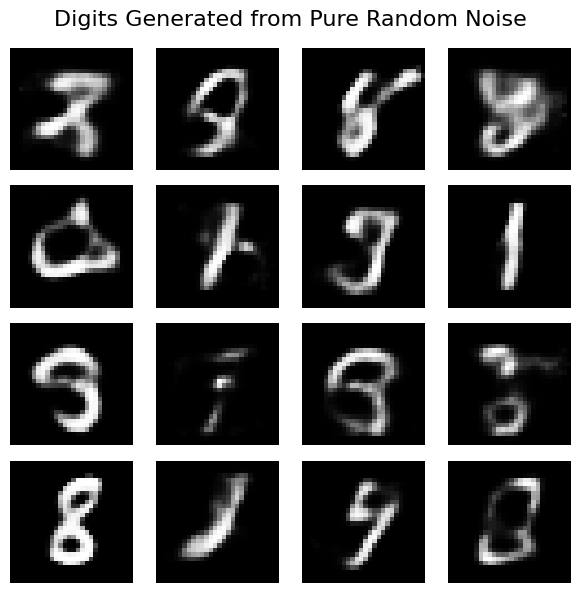

In [ ]:
# Sample from the latent space using the trained decoder
model.eval()
with torch.no_grad():
    n_samples = 16
    latent_dim = 20
    # Sample latent vectors from the standard normal prior, since the KL term
    # during training pushed q(z|x) towards N(0, I)
    z = torch.randn(n_samples, latent_dim).to(device)
    samples = model.decode(z).cpu()
    samples = samples.view(n_samples, 28, 28)

# Visualize the generated digits
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i], cmap='gray')
    ax.axis('off')
plt.suptitle("Digits generated from random latent vectors")
plt.tight_layout()
plt.show()

**Interpretation:** After training for enough epochs, the digits generated by feeding random $z \sim \mathcal{N}(0,I)$ vectors into the decoder look like recognizable, if slightly blurry, handwritten digits (a typical property of pixel-wise BCE loss with a simple fully-connected decoder). Most samples are plausible digit shapes rather than noise, and varying $z$ produces a smooth variety of digit styles/strokes. This indicates that the KL-regularization successfully shaped the latent space into a dense, continuous region that aligns with the standard normal prior — points sampled directly from $\mathcal{N}(0,I)$ correspond to valid points in the learned digit manifold, which is exactly the generative behaviour a VAE is designed to provide. Some outputs may still look ambiguous between digit classes (e.g. between a 4 and a 9), which is expected since nothing in training enforces hard class boundaries in the latent space — only smoothness and a Gaussian-like overall structure.